<a href="https://colab.research.google.com/github/MamoMGD1/ML_101/blob/main/notebooks/Section01_Supervised_Learning/Chapter00_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SUPERVISED LEARNING**

What is the idea of learning?  
Whenever we think about learning something or training someone for a task, we always would think of a **trainee (the learner)** and a **trainer (the teacher)**.  

- The job of the **trainer** is to teach, guide, and show the true and correct way of doing a task.  
- The job of the **trainee** is to try its best to capture some patterns, useful tricks, and techniques to absorb the trainer’s knowledge.  

This idea is present everywhere: from training athletes, to teaching a new language, to even training a dog to sit, stand, or perform a task.  

Surprisingly, the same idea exists in **training a machine**.  
You have a machine (computer, robot, program) to which you give clean and preprocessed **input data**, along with a **target** (you're basically telling, “given these inputs, I want these outputs”).  
The program then comes up with a **mathematical model** that has captured the pattern from all the training data and can lead to the desired outputs.  

---

### **A Beautiful Example**

Suppose we give a program the **temperature** and **humidity** of every day from the last month, plus the label of whether each day was *rainy* or *not rainy*.  
So all the program has is a dataset like this:

| Temperature (°C) | Humidity (%) | Rainy |
|------------------|--------------|-------|
| 12               | 80           | Yes   |
| 15               | 75           | Yes   |
| 25               | 40           | No    |
| 30               | 35           | No    |
| 10               | 90           | Yes   |

The program is asked to figure out a way to predict the output (*rainy or not rainy*) from the input values (*temperature and humidity*).  

We would expect it to understand patterns such as:  
- low temperature + high humidity → more likely rainy  
- high temperature + low humidity → probably not rainy  

The model will not build this idea from one or two days, but from the whole dataset. That’s why it becomes **generalizable and useful**.  

Why useful? Because the program can now predict whether it will rain on *any future day* given only its temperature and humidity. So, based on past data, we now have a program that can successfully predict the future.  

The same technique could be used to train a program to:  
- predict if a person has the risk of getting cancer or not,  
- estimate if a house will be sold in a certain price range,  
- detect if an email is spam or not,  
- identify whether a bank transaction is fraudulent,  
- or classify whether an image contains a cat or a dog.  

From this point on, we no longer call it a “program” — it is a **Model**, because it has learned to interpret true relationships between real-world variables (like temperature and humidity) with a mathematical model.  

---

### **Why "Supervised"?**

When we talk about this method of training a machine, what we need is a type of data called **Labelled Data**.  

Why? Because the target is already determined, labelled alongside the input data.  
In the weather example, the model received both the inputs (*temperature, humidity*) and the true targets (*rainy or not*).  

That is why this method is called **Supervised Learning** — the true labels supervise and guide the model’s behavior.  

Another method, called **Unsupervised Learning** (more on it in `Section02`), does not use labelled data. It instead tries to extract patterns from unlabelled data.  

But in this chapter, we start from the initial algorithm of Supervised Learning: **Regression**.  

# **REGRESSION**

So far we understood that we are supposed to have a dataset of some **features** and a **target variable**. We are then going to design a program that builds a **mathematical model** which takes those input values and gives us the output.  

We called this program a **model**, and the technique we used is **supervised learning** because we are explicitly specifying the targets to our model.  
But the real question is: **how does it figure out the relationships between our variables?**

From the previous chapters we remember:  
- Each of our data can be represented by a **point** (or a vector, but we’ll stick with point) in a **multi-dimensional space**.  
- The dimensions of this space come from the number of **features** we have for each data point.  

For example:  
- If our dataset has **two features** (like temperature and humidity), each data point is a point in a **2D space** (one axis = temperature, the other = humidity).  

But things change when we consider the **target values**:  

- If the **outputs (targets)** are **continuous numeric values**, the problem is called **Regression**, and the model is a **Regressor**.  
- If the outputs are **discrete values (classes)**, the problem is called **Classification**, and the model is a **Classifier** (more on this in the next chapter of this section).  

Suppose the inputs to our model are the **area of a house** and its **age**:  

- If we train the model to predict the **price of the house** (a continuous numeric variable), it’s a **Regression problem**.  
- If instead we train the model to predict whether the house will be **sold or not sold** (a discrete yes/no → 0 or 1), it’s not regression anymore — it’s a **Classification problem**, with its own algorithms.  

This chapter focuses on the different algorithms a model can use for **Regression**.


## **Linear Regression**

In the real world, many things are **connected** — one factor affects another in ways we can often see and measure.  
Think about it: the bigger a house is, the more it usually costs. The faster you run, the more calories you burn. The more years you study, the higher your expected income might be.

When the **relationship** between these factors is **linear**, we can draw a **straight line** through our data points to **capture the trend** — and then use that line’s **equation** to make predictions for new, unseen inputs.

---

### **How Does It Work?**
In **Linear Regression**, we find the line that best describes the relationship:
$$
y = m \times x + b
$$
where:
- **x** is the input variable,
- **y** is the predicted output,
- **m** is the slope (how much y changes as x changes),
- **b** is the intercept (the y-value when x = 0).

Once we have this line, we can **predict** any new value by plugging in a new **x**.

---

### **A Quick Example**

Imagine you’re trying to **predict the price of a small house** just based on its **size** in square meters.  
You’ve collected this tiny dataset:

| $x_{real}$ (Size) | $y_{real}$ (Price) |
|-------------------|---------------------|
| 100               | \$110,000           |
| 200               | \$300,000           |
| 300               | \$570,000           |
| 400               | \$720,000           |

So for:
- **100 $m^2$** → the house costs \$110k
- **200 $m^2$** → the house costs \$300k, and so on.

Your goal is to find a **line** that can predict the price for **any house size** in this neighborhood.

---

### **Two different models**

You decide to fit a line:
$$
\hat{y} = 1000x + 10000
$$

So your predicted prices for given data would be:
$$
[110,000,\; 210,000,\; 310,000,\; 410,000]
$$

Your friend tries another line:
$$
\hat{y} = 2100x - 100000
$$

and predicts:
$$
[110,000,\; 320,000,\; 530,000,\; 740,000]
$$

**So who’s closer?**

Let’s compare the real prices with the predictions for each house:

| Size | Real Price | Your Prediction | Friend’s Prediction |
|------|-------------|-----------------|---------------------|
| 1    | \$110,000   | \$110,000         | \$110,000             |
| 2    | \$300,000   | \$210,000        | \$320,000            |
| 3    | \$570,000   | \$310,000        | \$530,000            |
| 4    | \$720,000   | \$410,000        | \$740,000            |

Neither line predicts **perfectly** — there’s always a gap between the real price and the predicted one.

For example:
- For the third house, your model is **\$260,000 off**, your friend is only **\$40,000 off**.

---

### **Where Does This Error Come From?**

In real life, there’s no perfect formula that sets a house price. You can guess the pattern (*bigger houses cost more*), but there would always be people’s choices, negotiations, urgency to sell ... that is always unpredictable.  

It’s not like calculating the **area of a square** from its edge. That is simple: there’s a clear formula, everyone uses it, and it always gives the same result.  
Pricing a house doesn’t work that way! You could give the same house with the same features to two different people, and they might both put different prices on it based on their own wishes.  

---

We don’t need AI models for problems that have **clear formulas**.  
We need them for things that **cannot be calculated by a formula**.  

We train our models to approximate the best possible $f(x)$ in the following equation:  

$$
y(x) = f(x) + \epsilon
$$

- $y(x)$ → the real observed values  
- $f(x)$ → the mathematical model trying to get as close as possible to those real values  
- $\epsilon$ → the noise (the unpredictable part we can never model)  

Think of it this way:  
- If a house is really worth **\$300,000**, but I price it at **\$320,000**,  
- that extra **\$20,000** is the **$\epsilon$**, coming from my personal decision.  
- I could set it higher if I believed my house is worth more, or lower if I wanted a quick sale.  

The job of a **regressor** is to model the **real pricing pattern** — the $f(x)$ — regardless of the noise.  

When we build models, we’re really trying to **approximate the hidden rule** $f(x)$ — but we can never remove the noise. So our goal is to find the **best possible line** — the one that makes our **errors as small as possible**.

We need a **clear way to measure the errors**, so we can see which line gets us **closer to reality**.

Those measures are called **Loss Functions**: they give us a **number** that shows **how wrong** a model is — so we can compare between the models and pick the best one.

---


### **Visual Illustrations**

Before we dive into **Loss Functions**, let’s build an **intuitive feel** for what a good or bad model looks like.

Below is the real-world-inspired data of **40 healthy people’s weights** versus their heights.  
It’s reasonable to expect that **height and weight are related** — so we might guess that the data roughly follows a **straight line**.

In this example, we’ve fit **three different lines (models)** to the same data:

- **Model A:** A line with a **too-small slope**, which underestimates how weight increases with height.
- **Model B:** A line with a slope that might be too steep or with an intercept that shifts the line too far up or down.
- **Model C:** A line that seems to run **right through the cloud of points**, minimizing the overall distance between the data and the line — likely the **best fit**.

---

**Takeaway:**

* A **good regression model** finds the line that stays **closest to all the points** overall.
* A **bad regression model** misses the real trend — its line stays too far from many points.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

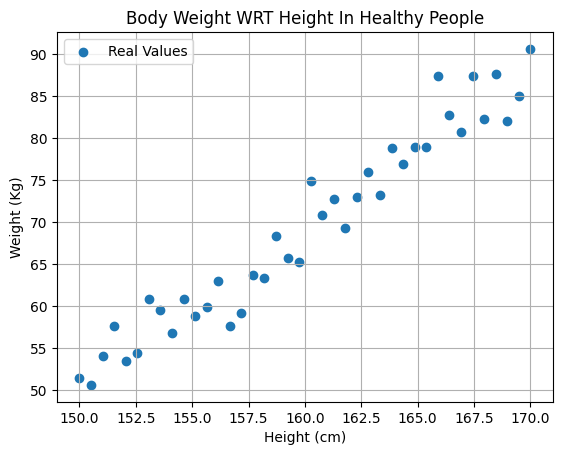

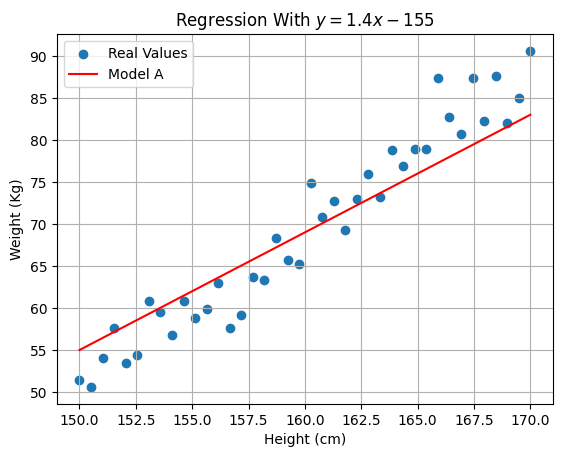

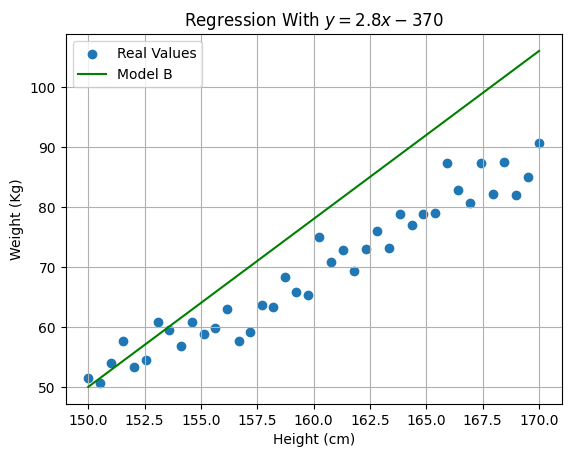

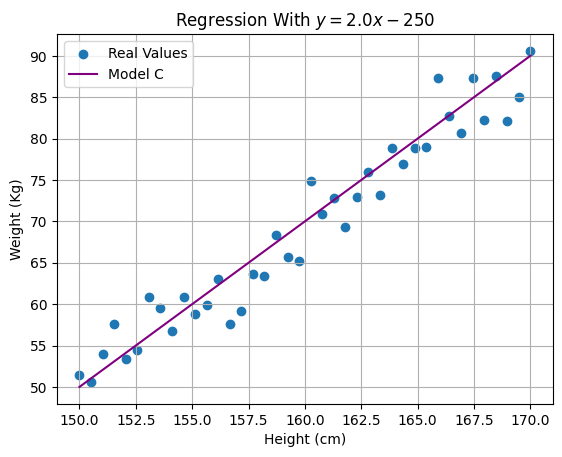

In [ ]:
n = 40
np.random.seed(42)

# Generate heights from the range 150 - 170 cm
real_x = np.linspace(150, 170, n)

# Calculate heights with height = 2 × weight - 250 + random noise
real_y = 2*real_x - 250 + np.random.normal(loc=0, scale=3, size=n)

# Show real data first
plt.scatter(real_x, real_y, label="Real Values")
plt.grid("on")
plt.title("Body Weight WRT Height In Healthy People")
plt.xlabel("Height (cm)")
plt.ylabel("Weight (Kg)")
plt.legend()
plt.show()

# Define 3 different models, models data: [slope, bias, color, name]
models = [
    [1.4, -155, "red", "A"],
    [2.8, -370, "green", "B"],
    [2.0, -250, "purple", "C"]
]

# Plot each model
for slope, bias, color, name in models:
    model_y = slope*real_x + bias

    plt.scatter(real_x, real_y, label="Real Values")
    plt.plot(real_x, model_y, color=color, label=f"Model {name}")
    plt.grid("on")
    plt.title(f"Regression With $y = {slope}x{bias:+}$")
    plt.xlabel("Height (cm)")
    plt.ylabel("Weight (Kg)")
    plt.legend()
    plt.show()

## **Loss Functions**

Let’s connect this back to our **house price prediction** example.

Remember:  
We tried **two models** for predicting house prices.  
Your friend’s model seemed **better**, because its predictions were **closer** to the real prices — the **errors** were smaller.

### **But what exactly is an error?**

In simple terms:
$$
\text{Error} = y_{real} - \hat{y}
$$

where:
- $y_{real}$ is the true value,
- $\hat{y}$ is the predicted value.

So, an **error** is just the difference between what actually happened and what our model guessed.

But we don’t care about the error for just **one house** — we care about **all the houses** in our data.  
So we add up all these differences:

$$
\text{Sum of Errors (SE)} = \sum_{i=1}^{n} (y_i - \hat{y}_i)
$$

But you might have noticed a problem: Sometimes your model predicts **too high**, sometimes **too low**.  
This means errors can be **positive or negative** — and when you sum them up, they can **cancel each other out**.

In fact, it’s possible for a terrible model to have a total error of **zero** just because the positive and negative parts balance out.

---

### **How do we fix this?**

Instead of just adding raw errors, we **square each one**:

$$
\text{Sum of Squared Errors (SSE)} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Squaring does two great things:

1️⃣ **All errors become positive** — so no canceling out.  
2️⃣ **Big mistakes are punished harder** — because large errors grow even more when squared.

**Example:**  
- Predicting **\$10,200** instead of **\$10,000** → Error = **\$200** → Squared Error = **\$40,000**  
- Predicting **\$100,000** instead of **\$10,000** → Error = **\$90,000** → Squared Error = **\$8,100,000,000**

The bigger the mistake, the bigger the punishment.

---

### **More practical metrics**

Because SSE can get huge, we often use its **average**:

$$
\text{Mean Squared Error (MSE)} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Still, MSE is in **squared units** (like dollars squared or kg squared). That’s weird.  
So we can sometimes take its **square root** to bring it back to the original units:

$$
\text{Root Mean Squared Error (RMSE)} = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 }
$$

Sometimes, your data has **big outliers** — unusual points far from the rest (like one house priced 5× higher than the neighborhood).

Because squaring errors makes big errors even bigger, you might not always want that.  
In such cases, you can use the **Mean Absolute Error (MAE)** instead:

$$
\text{Mean Absolute Error (MAE)} = \frac{1}{n} \sum_{i=1}^{n} | y_i - \hat{y}_i |
$$

Here, you just take the **absolute value** of each error — no squaring — then average them.  
This means:
- **All errors are positive** (so they don’t cancel).
- **Big errors** still count more, but they don’t explode like they do when squared.

So when you have **high-variation data** with possible **outliers**, MAE can give you a **more balanced measure**.

---

No matter which version you use — **SSE**, **MSE**, or **RMSE** — they all give you a clear **single number** to measure how far off your model is.

Lower **error → better model**.  
It’s that simple.

And because you now have a clear, consistent metric, you can:
- **Compare models** fairly.
- Track whether your tweaks are making predictions **better or worse**.

---

Next up: let’s see **how to actually find the best line** — by minimizing these errors!

In [ ]:
# Function to return different loss metrics from y and y_hat
def calculate_loss(y,y_hat,func="mse"):
  if func == "sse":
    return np.sum((y-y_hat)**2)

  elif func == "mse":
    return np.mean((y-y_hat)**2)

  elif func == "rmse":
    return np.sqrt(np.mean((y-y_hat)**2))

  elif func == "mae":
    return np.mean(np.abs(y-y_hat))

## **Analytical (Closed-Form) Solution**

The main goal of training any model is to **find the best parameters** that make its predictions as close as possible to the real values.  
These **parameters** are the numbers the model must **learn** — they control how the output changes given an input.

For a simple straight line:
$$
\hat{y} = mx + b
$$
- **m** = slope → controls the tilt of the line  
- **b** = intercept → controls where the line crosses the y-axis

Changing **m** and **b** changes the line, changes the predictions, and changes the **loss**.

### **The goal**

We want to find **which m and b** make our loss (error) **as small as possible**.  
Here, our loss is the **Sum of Squared Errors (SSE)** that we're going to represent with **$J(m,b)$**:

$$
J(m,b) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \sum_{i=1}^{n} (y_i - (mx_i + b))^2
$$

- The input data ($ x $) and the real outputs ($ y $) are **fixed** — they don’t change.
- The only things we can **adjust** are **m** and **b**.

So, we’re asking:  
**For which values of m and b does $J(m,b)$ reach its minimum?**

If you imagine **m** on the x-axis, **b** on the y-axis, and $J(m,b)$ on the z-axis, the loss surface forms a smooth **3D bowl shape** (a paraboloid).

The lowest point of this bowl is where our loss is the least which means a line with $m$ and $b$ values of that point fits the data **perfectly** (as best as possible).

---

### **The math trick**

From calculus, we know:  
At a **minimum**, the slope (first derivative) of a curve is **zero**.

So:
- Take the **partial derivative** of $J(m,b)$ w.r.t. $m$
- Take the **partial derivative** of $J(m,b)$ w.r.t. $b$
- Set both to **zero**
- Solve the resulting system of equations

---
### **Derivatives**

To find the best line, we must **minimize** the loss function $J(m,b)$:  

$$
J(m,b) = \sum_{i=1}^{n} (y_i - (mx_i + b))^2
$$

We take the **partial derivatives** with respect to $m$ and $b$, and set them equal to zero to find the **minimum**.

**1️⃣ Derivative w.r.t. m:**

$$
\frac{\partial J}{\partial m}
= \frac{\partial}{\partial m} \sum_{i=1}^{n} [\, y_i - (mx_i + b) ]^2
= -2 \sum_{i=1}^{n} x_i [\, y_i - (mx_i + b) ] = 0
$$

**2️⃣ Derivative w.r.t. b:**

$$
\frac{\partial J}{\partial b}
= \frac{\partial}{\partial b} \sum_{i=1}^{n} [\, y_i - (mx_i + b) ]^2
= -2 \sum_{i=1}^{n} [\, y_i - (mx_i + b) ] = 0
$$

These give us **two simple equations**:

$$
\sum_{i=1}^{n} [\, y_i - (mx_i + b) ] = 0
\quad \text{and} \quad
\sum_{i=1}^{n} x_i [\, y_i - (mx_i + b) ] = 0
$$

Solving this system gives us:

$$
b = \frac{s_{x^2} \cdot s_y - s_x \cdot s_{xy}}{s_{x^2} \cdot n - s_x^2},
\quad
m = \frac{s_{xy} - b \cdot s_x}{s_{x^2}}
$$

Where:
- $ s_x = \sum x_i $
- $ s_y = \sum y_i $
- $ s_{xy} = \sum x_i y_i $
- $ s_{x^2} = \sum x_i^2 $
- $ n $ = number of samples

And that’s it!  
Plug in your sums → get **m** and **b** → you have the **optimal line** that minimizes the loss.

---

## **Takeaway**

✅ **Minimizing SSE** automatically minimizes **MSE**, **RMSE**, and other variations.  
✅ The **analytical solution** works perfectly for **simple linear regression**.  
✅ For larger, more complex problems (like thousands of features or more advanced models), we’ll switch to **Gradient Descent** — a flexible, powerful way to find the minimum without solving big equations by hand.


In [ ]:
# Function to calculate the optimum m and b using analytical solution
def analytical_lin_regression(x,y):
  s_x = np.sum(x)
  s_y = np.sum(y)
  s_xy = np.dot(x,y)
  s_x2 = np.sum(x**2)
  n = len(x)
  b = (s_x2*s_y - s_x*s_xy)/(s_x2*n-s_x**2)
  m = (s_xy-b*s_x)/s_x2
  return m,b

# Function to calculate mx+b
def predict(m,x,b):
  return m*x+b

###**Hamid’s Ice Cream Troubles**

Let’s meet **Hamid** — a little boy with a small ice cream stand and a problem in his small ice cream business:  
He must prepare **just the right amount** of cream and ice for tomorrow’s sales.  
If he makes **too little**, he’ll miss out on sales.  
If he makes **too much**, it melts and goes to waste — money lost!

But… how can Hamid know how many ice creams he’ll sell **tomorrow**?  
He’s not a magician — he can’t see the future!

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S01_C00/hamid.png" width="500">
</div>

The only thing Hamid has is:
- A simple **list of past sales** (how many ice creams he sold on different days).
- He also knows one thing for sure: **the hotter the weather, the more people buy ice cream**.

So Hamid gets an idea:  
He looks up the **temperatures** for those days from the internet.  
Then, he plots a **scatterplot**:  
- **X-axis**: temperature  
- **Y-axis**: number of ice creams sold

And guess what?  
Hamid notices something amazing:  
The points seem to line up in a **rough line** — higher temperatures → more sales!

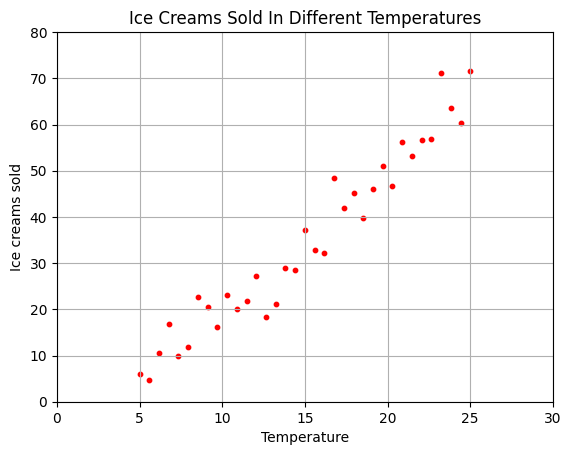

In [ ]:
# Generate random temperatures and ice creams sold
np.random.seed(42)
n = 35
noise = 5
temps = np.linspace(5,25,n)

# The real function ice creams sold = 3.2 × temperature - 12.5 + random noise
ice_creams = 3.2 * temps - 12.5 + np.random.normal(loc=0,scale=noise,size=n)
plt.scatter(temps,ice_creams,c='red',s=10)
plt.xlim(0,30)
plt.ylim(0,80)
plt.title('Ice Creams Sold In Different Temperatures')
plt.xlabel('Temperature')
plt.ylabel('Ice creams sold')
plt.grid()
plt.show()

**Hamid fits his line**

Hamid tries the **analytical solution** — and gets these results:

$$
m = 3.08,\quad b = -11.38
$$

**What does this mean?**

- For every **1 °C increase** in temperature, Hamid can expect to sell about **3 more ice creams**.
- At **0 °C**, the model *theoretically* predicts about **-11.38** ice creams — of course, you can’t sell negative ice creams!  
  This just shows that when the temperature is about **4 °C** you would expect your sales to start.

---

Hamid plots this line over his scatterplot.  
It’s not perfect — the line doesn’t hit every point exactly.

But that’s okay!  
In the real world, **no single rule** perfectly controls ice cream sales.  
People’s moods, rain, school holidays, and a dozen other things cause *random noise* that the model can’t see.

We shouldn't forget that we're just predicting the $f(x)$ part of the equation, that $\epsilon$ is not predictable:

$$
y = f(x) + \epsilon
$$

Still, Hamid’s line **follows the overall pattern**:
- Higher temperature → more sales.
- If you asked someone: *“How many ice creams do you think Hamid might sell on a 27 °C day?”*  
  Most would guess *somewhere between 70 and 80* (based on the scatterplot).

Hamid’s model predicts:

$$
\hat{y} = 3.08 \times 27 - 11.38 \approx 71.81
$$

---

**How good is this prediction?**

It won’t be exact — there’s always some **average error**. One way to describe it is with the **Mean Absolute Error (MAE)**:  
It tells Hamid, *on average*, how many ice creams the model is **off by**.

If Hamid’s MAE is about **8.85**, that means:
> He can roughly expect his real sales to be within about **±9 ice creams**, but note that this is not a formal confidence interval — just a useful ballpark.

---

That’s it!  
Hamid now has a **simple model** that helps him plan tomorrow’s ice cream stock — and he didn’t need to guess blindly!


Ice creams needed for 27 °C: 71.81 ∓ 8.85*



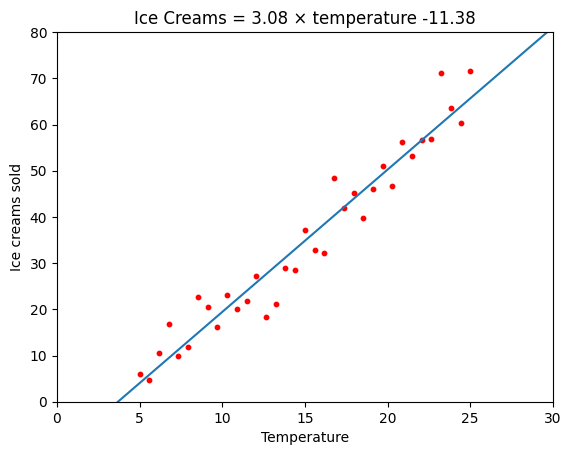

In [ ]:
# Calculate the m and b using the analytical solution
m,b = analytical_lin_regression(temps,ice_creams)
line_x = np.linspace(0,30,n)
ice_creams_pred = predict(m,line_x,b)

# Calculate the MAE loss for the current model
mae = calculate_loss(ice_creams,ice_creams_pred,func="mae")

pred = predict(m,27,b)
print(f"\nIce creams needed for 27 °C: {pred:.2f} ∓ {mae:.2f}*\n")

plt.scatter(temps,ice_creams,c='red',s=10)
plt.plot(line_x,ice_creams_pred)
plt.xlim(0,30)
plt.ylim(0,80)
plt.title(f'Ice Creams = {m:.2f} × temperature {"+ " if b>=0 else ""}{b:.2f}')
plt.xlabel('Temperature')
plt.ylabel('Ice creams sold')
plt.grid()
plt.show()

### **Multiple Linear Regression**

So far, we’ve seen how a simple line fits data in **one dimension** (1 feature) — like Hamid’s ice cream sales being affected by just one variable (the temperature.)

But what if we have **more than one feature**?  
For example, predicting house price using:
- Size in m²
- Number of rooms
- Age of the building

This is called **Multiple Linear Regression** — where the decision boundary is no longer a simple line but a **hyperplane** in higher dimensions.

💡 **A quick note about dimensions:**

- In **2D**, our decision boundary is a line.
- In **3D**, it’s a plane (like a big flat sheet).
- In **4D and beyond**, it’s a **hyperplane** — impossible to *visualize*, but easy for a computer to handle!

---

#### **Minimization of Loss Function (J)**

For multiple linear regression, we still minimize the **Sum of Squared Errors (SSE)**, but this time instead of explicit parameters like $m$ and $b$ we would use a list of parameters that we call **weights** and represent with $\mathbf{w}$:

$$
J(\mathbf{w}) = \text{SSE} = \sum_{i=1}^m (y_i - \hat{y}_i)^2
\quad \text{where} \quad
\hat{y}_i = w_0 + w_1 x_{i1} + w_2 x_{i2} + \dots + w_n x_{in}
$$

#### **Partial Derivative**

To find the best weights, we take the partial derivative with respect to **each weight**:

$$
\frac{\partial J}{\partial w_j} = 0 \quad \text{for each } j.
$$

In **matrix form**, this gives the **Normal Equation**:

$$
\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}.
$$

---

#### **What this means**

- $X$ is your input **matrix** — size **(m × n)**, where:
  - **m** = number of samples  
  - **n** = number of features (plus a column of 1’s for the intercept)

- $\mathbf{y}$ is your **target vector** — real outputs.

- $\mathbf{w}$ is your **weight vector**:
  - $w_0$ = intercept (bias term)
  - $w_1, w_2 \dots w_n$ = coefficients showing how much each feature affects the output.

In [ ]:
# Function to return the weights for a Multiple Linear Regression problem
def multi_lin_regression(x,y):
  return np.linalg.inv(x.T@x)@x.T@y

# Function to calculate X . w when X is inputs matrix and w is a list of weights
def mlr_predict(x,w):
  x = np.append([1],x)
  pred = x @ w
  return pred[0]

### **Morsal's Food Pricing Strategy**

Meet **Morsal**, the new manager of a popular restaurant.

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S01_C00/morsal.png" width="500">
</div>

Morsal wants to update the menu and set fair, profitable prices for new dishes. But there’s a problem:

**She knows exactly *what* goes into each dish** — how many grams of meat, how much rice, how many chicken legs, how much vegetable, how much oil — but she has **no idea** how much *each* ingredient really contributes to the final price.

Should she just guess?
She could — but random guesses mean risking **underpricing** (and losing money) or **overpricing** (and losing customers). That’s no way to run a business.

---

#### **What Morsal *does* have**

Luckily, Morsal has a small dataset:
For about **40 dishes**, she knows:

* The exact amounts of meat, rice, chicken, vegetables, and oil.
* The **final price** each dish sold for.

What she doesn’t know are the **hidden rules** that connect ingredients to the prices.

Morsal is *sure* there’s a simple, logical pattern:

> “The total price must be a combination of the individual costs of each ingredient.”

Mathematically, that means:

> **Price = meat’s value × grams + rice’s value × cups + chicken’s value × legs + … + bias**

But *how* can she find those unknown values (weights) for each ingredient?
This is where **multiple linear regression** comes in:

> A way to **learn** how much each ingredient contributes to the price — using the data she already has.

---

#### **The Data Matrix**

In practice, Morsal:

* Puts each dish’s ingredients into a row.
* Builds an **input matrix X** with **5 features**: meat, rice, chicken, vegetable, oil.

But here’s a twist:
**We must also handle the intercept (bias).**

Every linear regression needs a constant baseline.
To include that in the math, we add an **extra column of 1’s** to the **beginning** of `X`.
This extra column lets the model learn an intercept **automatically**.

With this setup, Morsal uses the **analytical (closed-form) solution**:

$$
\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}
$$

Here:

* $\mathbf{X}$ is now a **40×6** matrix → \[1, meat, rice, chicken, vegetable, oil].
* $\mathbf{w}$ is a **6×1** vector → \[bias, meat’s value per gram, rice’s value per cup, chicken’s value per leg, …]

---

#### **How to predict a new dish**

When Morsal wants to price a **new dish**, say:

* 0g meat, 0.5 cup rice, 0 chicken legs, 100g vegetables, 0.02 cup oil.

She must:

* Write it as a vector `[0, 0.5, 0, 100, 0.02]`.
* Add a **1 at the start** to represent the bias.

So, the final input is `[1, 0, 0.5, 0, 100, 0.02]`.

Then multiply it with weights ($\mathbf{w}$):

$$
\text{price} = \mathbf{x} \cdot \mathbf{w}
$$

#### **Key lesson**

**Multiple linear regression** is powerful:

* It finds **weights** for each *dimension* (feature).
* It uses the **bias term** by adding a **column of ones**.
* It works for *any* number of dimensions — even if we can’t visualize them!

> **Don't forget**: For the analytical solution, we don’t have to scale the features — the math still works!

In [ ]:
n = 40
np.random.seed(42)

# Creating random ingredients for foods
meat = np.random.randint(0,200,n)
rice = np.random.random(n)
chicken = np.random.randint(0,3,n)
vegetable = np.random.randint(0,100,n)
oil = np.random.random(n)/2

x_values = np.column_stack((meat,rice,chicken,vegetable,oil))

# Create prices for each of the foods
coef = np.array([5,2,3,1,0.5]).reshape(-1,1)
y_values = x_values@coef + np.random.normal(loc=0,scale=1,size=n).reshape(-1,1)

# Featured matrix with the first column full of ones (to represent the bias)
x_values = np.column_stack((np.ones(n),x_values))
w = multi_lin_regression(x_values,y_values)

# Calculate the price of two new foods (a vegan and a high protein food)
new_vegan_food = np.array([0,0.5,0,100,0.02])
calories_rich_food = np.array([250,0.5,4,10,0.25])
vegan_food_price = mlr_predict(new_vegan_food,w)
calories_food_price = mlr_predict(calories_rich_food,w)

print(w)
print(f'\nVegan Food Price: {vegan_food_price}')
print(f'Calories Rich Food Price: {calories_food_price}')

[[0.51111222]
 [4.99727737]
 [2.25275116]
 [2.97270826]
 [0.99638773]
 [0.73519441]]

Vegan Food Price: 101.29096442369742
Calories Rich Food Price: 1272.9953385282636


###**Solving Puzzles with MLRs**

You might think this idea of multiple linear regression only works for fancy data — but guess what?
It’s exactly the same idea behind those classic “scale riddles” you see online!

For example, look at this one:

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S01_C00/riddle.png" width="500">
</div>

**Image Credit:** [Original Website](https://iscs-zug.ch/new-mindbender-monday-3/)

You can think of this puzzle as a **simple system of 3 linear equations** with 3 unknowns:

* Dog’s weight
* Cat’s weight
* Rabbit’s weight

There’s no fancy “noise” here — so it’s an exact solution.
We can write the system as a matrix `X` (each row represents which animals exist [dog, cat, rabbit]) and vector `y` (total final weight), then solve:

$$
X =
\begin{bmatrix}
0 & 1 & 1 \\
1 & 0 & 1 \\
1 & 1 & 0
\end{bmatrix}, \quad
y =
\begin{bmatrix}
10 \\
20 \\
24
\end{bmatrix}
$$

And we solve:

$$
w = (X^T X)^{-1} X^T y
$$

Boom — just like that, the closed-form solution gives us:

* **Dog:** 17 kg
* **Cat:** 7 kg
* **Rabbit:** 3 kg

So the total when they all hop on the scale together is:
**17 + 7 + 3 = 27 kg**

This might seem playful, but it’s exactly the same math behind **multiple linear regression** and **system of linear equations** — just with no noise and no bias column (we don’t need an intercept because there’s no “base weight” with no animals on the scale).

In [ ]:
# order of the animals: dog, cat, rabbit
x_values = np.array([
    [0,1,1],
    [1,0,1],
    [1,1,0]
])
y_values = np.array([10,20,24]).reshape(-1,1)

# no biases needed in this problem so there is no need to add a unit column
w = multi_lin_regression(x_values,y_values)

print(w)
fourth_img = np.array([1, 1, 1])
print(f'\nWeight In The 4th Image: {np.dot(fourth_img,w)[0]} Kg')

[[17.]
 [ 7.]
 [ 3.]]

Weight In The 4th Image: 27.0 Kg


### **Polynomial Regression**

So far we’ve talked about lines — but let’s be honest:
**Nature doesn’t always draw in straight lines!**

- Trees don’t grow exactly taller by a fixed amount each year.

- The speed of a car doesn’t always increase at a constant rate when you press the pedal.

- The price of a stock rarely follows a perfect straight trend.

Real-world relationships are often **non-linear** — they bend, curve, and twist.
That’s why we need **Polynomial Regression**.

---

#### **What’s the idea?**

Imagine you’re trying to fit a curve through some points that clearly don’t line up nicely.
A straight line won’t cut it — but a **curve**, like a parabola or a higher-degree polynomial, might fit perfectly!

In polynomial regression, we don’t invent a whole new method — we can **expand** the features:

* We add **powers** of our input variable $x$ as extra features.
* For example, if we want a 3rd-degree polynomial:

  * Our feature matrix should include $x, x^2,$ and $x^3$ … each with its own weight to learn.

So in truth, **polynomial regression is just multiple linear regression** —
but with clever **feature engineering** to capture curves.

---

#### **Who decides the degree?**

You do!
You choose how many powers of `x` to include:

* A **degree 1** polynomial → Straight line.
* A **degree 2** polynomial → Quadratic curve.
* A **degree 3+** → More bends and wiggles.

This means you’re **choosing how many parameters** your model will learn.

⚠️ **But wait — more isn’t always better!**

Remember Bholu and Kabir's story from `Section00-Chapter00`?

If you keep adding **more features** — like `x⁴`, `x⁵`, `x⁶`, … your model becomes too flexible.
It starts to **memorize every tiny bump** in the data — even the **random noise**.

This is called **overfitting** — the model learns details that aren’t general patterns.
So, while your curve might hug your training data perfectly, it might **fail miserably** on new, unseen data.

On the flip side, if your polynomial degree is too low, you might miss real patterns —
the model will be **too stiff** to capture the true shape.
That’s **underfitting** — it doesn’t learn enough.

So, just like Kabir shouldn’t use irrelevant clues about the elephant,
you shouldn’t keep adding unnecessary powers of `x`.

A good model is like a smart detective — it ignores irrelevant details and focuses on the **real signal**.

In [ ]:
# Function to create features from 1 to x^m
def gen_features(x,m):
  x_values = np.zeros((len(x),m+1))
  for i in range(m+1):
    x_values[:,i] = x**i
  return x_values

def poly_reg_predict(x,w):
  pred = x @ w
  return pred

print(gen_features(np.array([1,2,3,4]),4))

[[  1.   1.   1.   1.   1.]
 [  1.   2.   4.   8.  16.]
 [  1.   3.   9.  27.  81.]
 [  1.   4.  16.  64. 256.]]


### **How Many Parameters?**

Imagine you have **50 data points** from some unknown true relationship:

$$
y = f(x) + ϵ
$$

where $f(x)$ is the hidden pattern, and $\epsilon$ is the unavoidable noise. Your goal is to figure out the best **polynomial curve** that captures $f(x)$ —
**without getting tricked by the noise!**

It’s entirely **up to you** how flexible you want your curve to be.
Add more powers of *x*, and your curve hugs tighter.
But add too many, and it starts hugging the noise too!

So how do we find the **perfect balance**?

---

### **Train-Test Split**

Here’s the classic approach:

✅ **Step 1:** Split your data.
Use **35 points** for **training** and keep **15 points** aside for **testing**.

✅ **Step 2:** Fit your polynomial model.
Start with just a few powers of *x*.

✅ **Step 3:** Measure **Mean Absolute Error $J(w)$**:

* Once on the **training set** → *train error*
* Once on the **testing set** → *test error*

At first, with too few parameters you will see:

* **Train error:** high
* **Test error:** high

Your model is **underfitting** — it can’t capture the real pattern.

By adding more powers of *x*:

* Both **train** and **test** errors **drop**.
* Good! Your model is learning real patterns.

But if you keep adding more and more:

* **Train error:** keeps shrinking to zero (since it starts learning the noises and outliers too).
* **Test error:** stops improving… it might even **rise again**!

Why? Your model is now **overfitting** — memorizing noise in the training data but failing to **generalize**.

The sweet spot is that magical moment where:

* **Train error:** low (model does its best to capture the pattern)
* **Test error:** also low (model can generalize well to unseen data)

This is your best model — flexible enough to learn, but disciplined enough to ignore noise.

So next time you fit a curve, remember:
> **Adding parameters is power — but power needs control.** Cost function is your guide to find the balance between **underfitting** and **overfitting**.

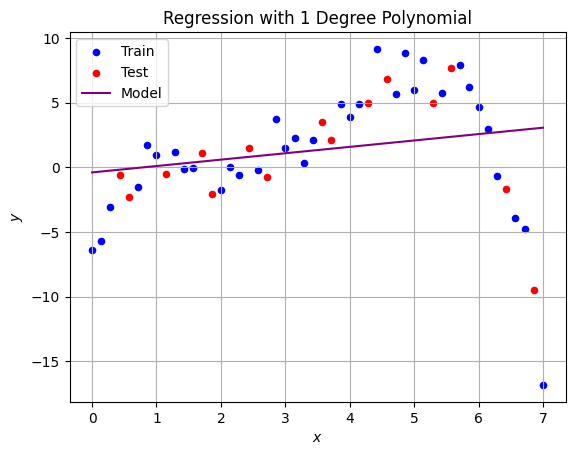

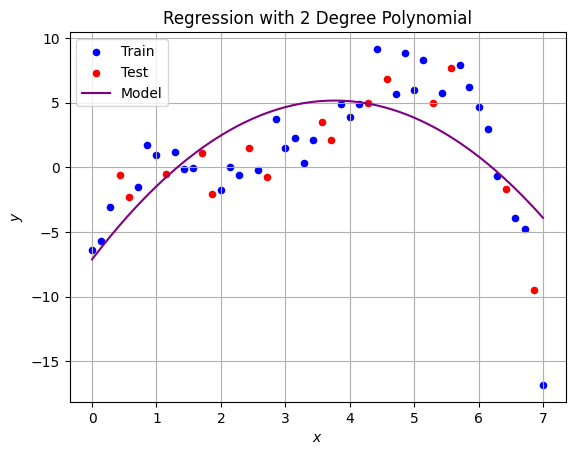

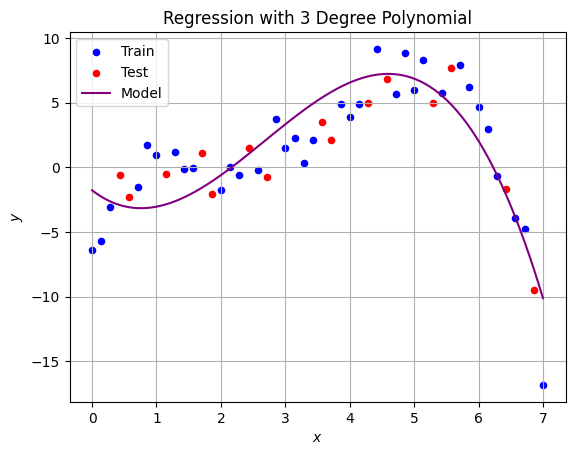

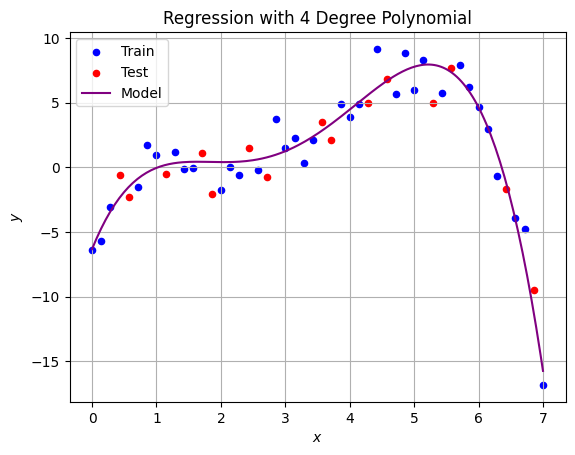

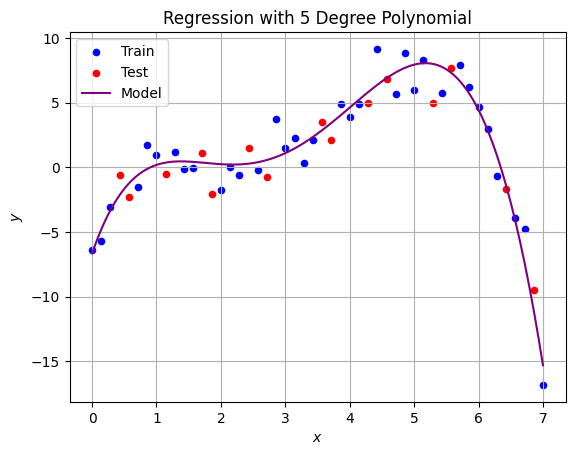

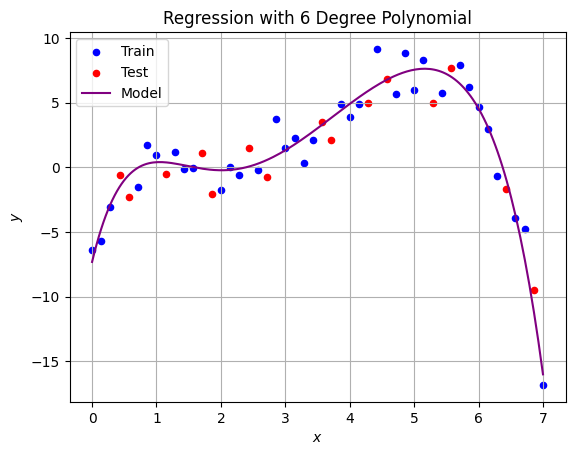

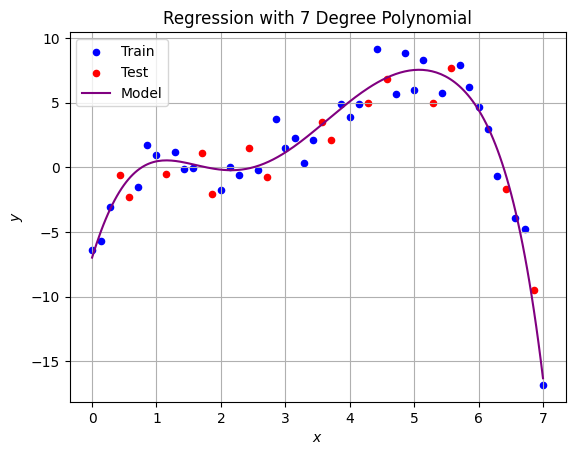

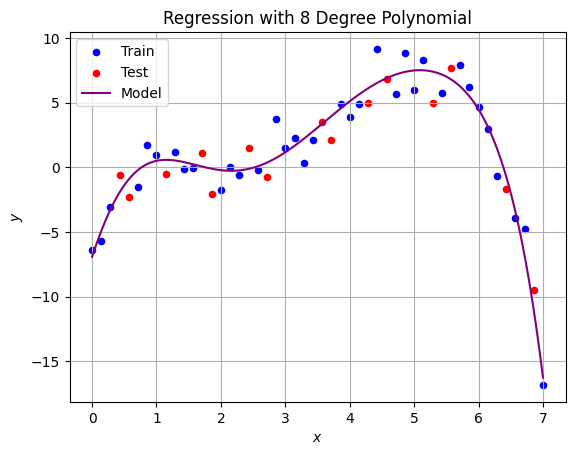

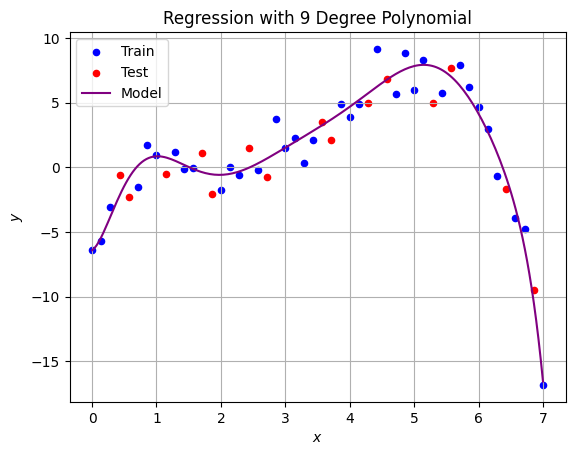

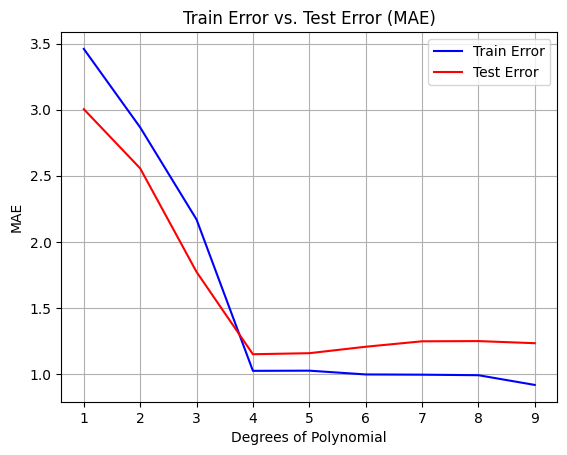

In [ ]:
from sklearn.model_selection import train_test_split

n = 50
m = 9
np.random.seed(42)

# Generate values with a wiggly function + random noise
x_values = np.linspace(0, 7, n)
y_values = (-(x_values-2)**4+4*(x_values-2)**3+(x_values-2)**2+2*x_values+1)/6 + np.random.normal(loc=0,scale=1.5,size=n)

x_train, x_test, y_train, y_test = train_test_split(x_values, y_values, test_size=15, random_state=42)

train_errors = []
test_errors = []

for i in range(m):
    # Generate features for train
    x_poly_train = gen_features(x_train, i + 1)
    x_poly_test = gen_features(x_test, i + 1)
    w = multi_lin_regression(x_poly_train, y_train)
    y_poly_train = poly_reg_predict(x_poly_train,w)
    y_poly_test = poly_reg_predict(x_poly_test,w)

    # Make predictions for smooth curve
    x_smooth = np.linspace(min(x_train), max(x_train), 200)
    x_poly_smooth = gen_features(x_smooth, i + 1)
    y_hat_smooth = poly_reg_predict(x_poly_smooth, w)

    train_errors.append(calculate_loss(y_train,y_poly_train,func="mae"))
    test_errors.append(calculate_loss(y_test,y_poly_test,func="mae"))

    plt.scatter(x_train, y_train, s=20, color='blue', label='Train')
    plt.scatter(x_test, y_test, s=20, color='red', label='Test')
    plt.plot(x_smooth, y_hat_smooth, color='purple', label='Model')
    plt.title(f'Regression with {i + 1} Degree Polynomial')
    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.grid()
    plt.legend()
    plt.show()

# Plot train and test errors through different degrees of polynomial
parameters = np.linspace(1,len(train_errors),len(train_errors))
plt.plot(parameters,train_errors,color="blue",label="Train Error")
plt.plot(parameters,test_errors,color="red",label="Test Error")
plt.title("Train Error vs. Test Error (MAE)")
plt.xlabel('Degrees of Polynomial')
plt.ylabel('MAE')
plt.grid()
plt.legend()
plt.show()

## **Gradient Descent**

So far, we’ve seen how **closed-form (analytical) solutions** can find the *perfect* line or hyperplane for linear regression — fast and exact.
It’s beautiful, neat math: plug in your data, solve a system of equations, done.
But here’s the catch:

> **Real-world data is rarely so simple.**

Imagine you’re working with:

* **Millions of features** (think of images with 1 million pixels each).
* **Complex, non-linear models** (like complex tabular data with unknown relationships between variables).
* **Huge datasets** where computing $(X^TX)^{-1}$ is too slow or impossible because the matrix is not invertible.

Closed-form breaks down:

* **Numerical instability** with huge matrices.
* **Impossible to invert** when your data is redundant or collinear.
* **No closed-form** even exists for some models (non-linear, deep networks).

So — what do we do when we can’t solve for the minimum loss in one shot?
**We *search* for it instead.**

---

### **The Gradient Descent Story**

Picture yourself on a mountain range — you’re standing somewhere up high on a foggy hill.
Your goal is to **find the lowest valley around you** — that’s our minimum loss.

You can’t see the whole mountain — but you *can* feel the slope under your feet:

* If it’s steep, you know you should step *faster* downhill.
* If it’s almost flat, you know you’re getting close — so you step *carefully* to avoid missing the lowest dip.

In machine learning, that “slope” is just the **derivative** of the loss function with respect to each parameter in a spot.

> Steeper slope means you need to take a **bigger step** and a flat slope requires a **smaller step.**

This is exactly what **Gradient Descent** does:

* It checks how changing each parameter affects the loss (**the gradient**).
* It *nudges* the parameters downhill step by step.
* It keeps doing this until it finds the point where the slope is zero — the lowest valley, the *minimum loss*.

---

### **How Gradient Descent Works**

At its heart, gradient descent repeats this simple update step until we find the best weights:

$$
w = w - \eta \nabla J
$$

* **\$w\$** → The model’s **parameters** (the weights we’re trying to learn).
* **\$\eta\$** → The **learning rate**, a small number that controls **how big each step should be**.
* **\$\nabla J\$** → The **gradient** of the cost function **\$J\$**, which tells us **how steep the slope is** and **in which direction to move** to reduce the error.

---

### **What Is The Gradient?**

The **gradient** is just a fancy word for a **vector of partial derivatives**:

$$
\nabla J =
\begin{bmatrix}
\frac{\partial J}{\partial w_0} \\
\frac{\partial J}{\partial w_1} \\
\vdots \\
\frac{\partial J}{\partial w_n}
\end{bmatrix}
$$

Each piece shows **how much** the cost would change if we tweak **one weight** a little bit.
Together, they point to the **fastest direction downhill**!

In each step, we look at the slope, **adjust the weights**, and step closer to the **lowest valley** — the place where our **loss is smallest**.


In [ ]:
# A made-up cost function with its derivative
def j_function(w0, w1):
  return (w0 - 2)**2 + (w1 + 3)**2

def j_derivative(w0, w1):
  dw0 = 2 * (w0 - 2)
  dw1 = 2 * (w1 + 3)
  return np.array([dw0, dw1])

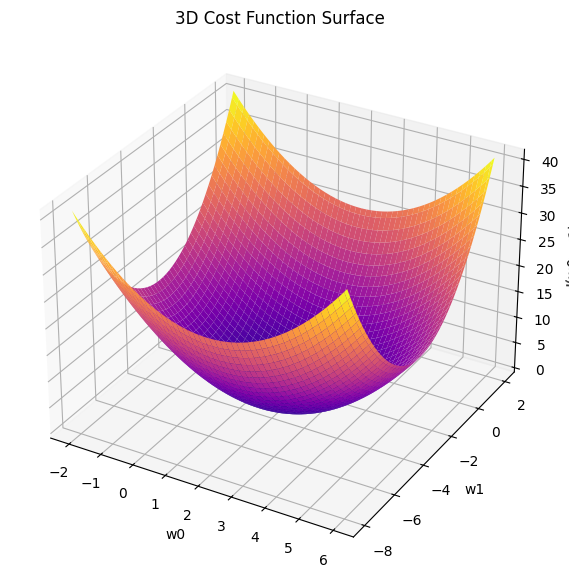

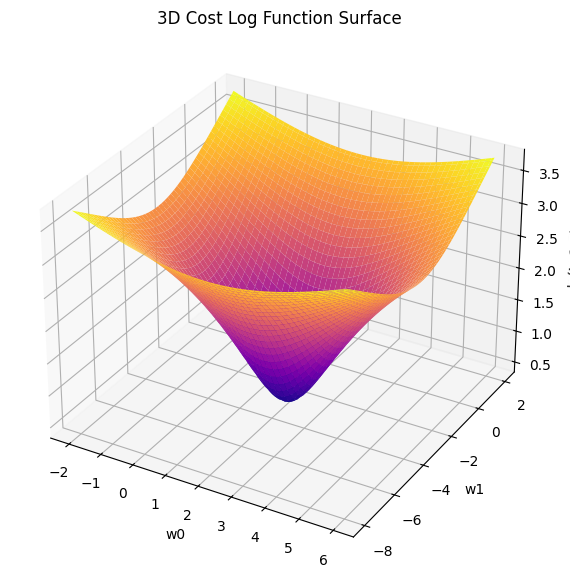

In [ ]:
w0 = np.linspace(-2, 6, 100)
w1 = np.linspace(-8, 2, 100)
W0, W1 = np.meshgrid(w0, w1)
Z = j_function(W0, W1)

# 3D Plot
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W0, W1, Z, cmap='plasma')
ax.set_xlabel('w0')
ax.set_ylabel('w1')
ax.set_zlabel('J(w0, w1)')
ax.set_title('3D Cost Function Surface')
plt.show()

# 3D Plot
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W0, W1, np.log(Z+1.5), cmap='plasma')
ax.set_xlabel('w0')
ax.set_ylabel('w1')
ax.set_zlabel('ln(J+1.5)')
ax.set_title('3D Cost Log Function Surface')
plt.show()

Final Weights: [ 1.99504824 -2.9938103 ]



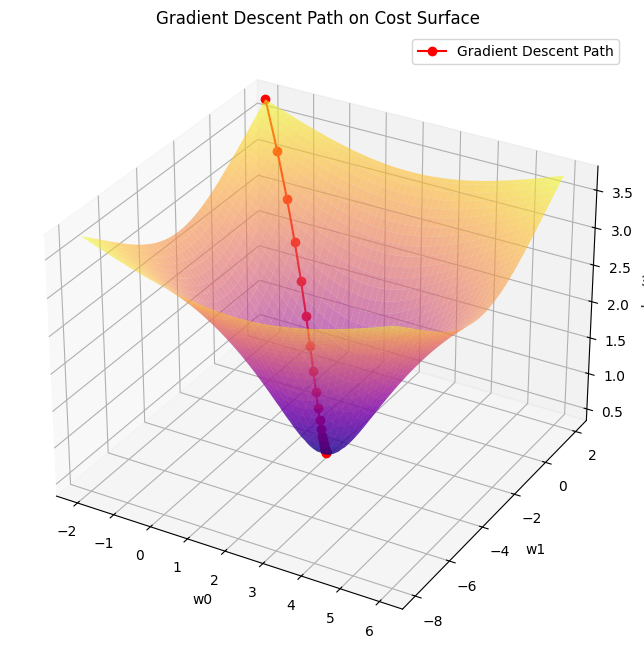

In [ ]:
def gradient_descent(init_w, j_derivative=j_derivative, learning_rate=0.1, iterations=100):
  w = init_w.copy()
  history = [w.copy()]

  for i in range(iterations):
    grad = j_derivative(w[0],w[1])
    w = w - learning_rate * grad
    history.append(w.copy())

  return np.array(history)

# Run gradient descent
init_w = np.array([-2,2])

history = gradient_descent(init_w, learning_rate=0.1, iterations=30)

print(f'Final Weights: {history[-1]}\n')
# Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Surface
ax.plot_surface(W0, W1, np.log(Z+1.5), cmap='plasma', alpha=0.6)

# Path
path = np.array(history)
ax.plot(path[:, 0], path[:, 1], np.log(j_function(path[:, 0], path[:, 1]) + 1.5),
        color='red', marker='o', label='Gradient Descent Path')

ax.set_xlabel('w0')
ax.set_ylabel('w1')
ax.set_zlabel('log(J)')
ax.set_title('Gradient Descent Path on Cost Surface')
ax.legend()
plt.show()

###**Types of Gradient Descent**

- So far, what we used is called **Batch Gradient Descent** — it calculates the gradient using **the whole dataset** in every step.  
It is **good for small datasets**, but when data gets huge, computing the full gradient becomes **slow and memory-heavy**.

- On the other end, there’s **Stochastic Gradient Descent (SGD)**: Instead of using the whole dataset, **SGD updates the weights using just one random data point** each time. It is **very fast and light** but the path jumps around **noisily** and may overshoot the minimum a lot.

- Between these two sits the hero: **Mini-Batch Gradient Descent** — the practical standard.
It splits the data into **small batches** (like 32 or 64 samples), computes the gradient for each batch, and updates the weights. It's **faster** than full batch, **smoother** than SGD, and works well for training **deep learning models**.

---

In practice:

* **Batch** → for small, simple problems.
* **SGD** → for online learning, huge streams of data.
* **Mini-Batch** → your go-to for **big data & neural networks**!

**Keep in mind:**
Gradient Descent is not just for simple lines — it’s the backbone of modern machine learning and deep learning.
You’ll see it over and over when we tackle **neural networks, logistic regression, deep learning**, and beyond.

In [ ]:
np.random.seed(42)

def extended_gradient_descent_1D(X, y, init_w, learning_rate=0.01, n_iters=50, mode='sgd', batch_size=16):
    w = init_w.copy()
    history = [w.copy()]
    m = len(X)

    for i in range(n_iters):
        if mode == 'sgd':
            # Single random point per iteration
            idx = np.random.randint(m)
            X_batch = X[idx:idx+1]
            y_batch = y[idx:idx+1]

            grad = j_derivative(w[0], w[1], X_batch, y_batch)
            w -= learning_rate * grad
            history.append(w.copy())

        elif mode == 'mbgd':
            # Shuffle the data at the beginning of each epoch
            indices = np.random.permutation(m)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            # Loop through all mini-batches
            for start in range(0, m, batch_size):
                end = start + batch_size
                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]

                grad = j_derivative(w[0], w[1], X_batch, y_batch)
                w -= learning_rate * grad
                history.append(w.copy())

        else:
            raise ValueError("Mode must be 'sgd' or 'mbgd' for this demo.")

    return np.array(history)

# Cost function: simple SSE for y = wx + b (w0 = bias, w1 = slope)
def j_function(w0, w1, X, y):
    y_hat = w0 + w1 * X
    return np.sum((y - y_hat)**2)

# Gradient of the cost function w.r.t [w0, w1]
def j_derivative(w0, w1, X, y):
    m = len(X)
    y_hat = w0 + w1 * X
    dw0 = -2 * np.sum(y - y_hat)
    dw1 = -2 * np.sum(X * (y - y_hat))
    return np.array([dw0 / m, dw1 / m])

Stochastic GD Final Weights: [-1.23828368  2.77177453]
Mini-Batch GD Final Weights: [-1.21856941  3.08140927]


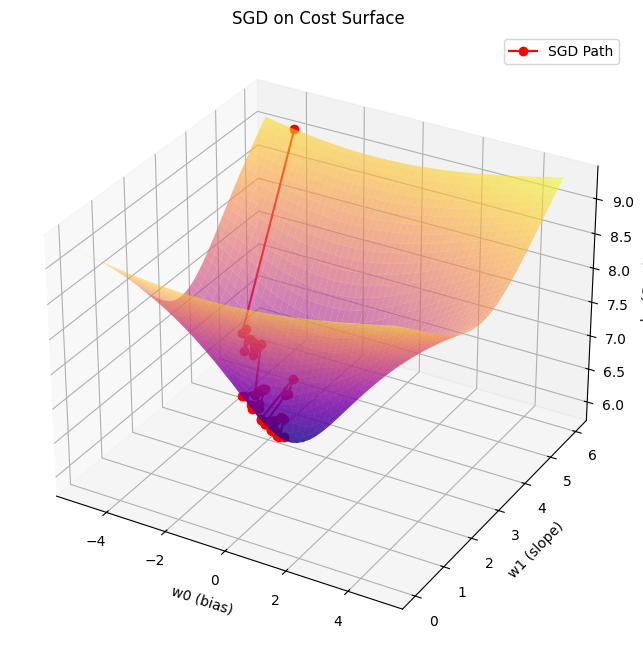

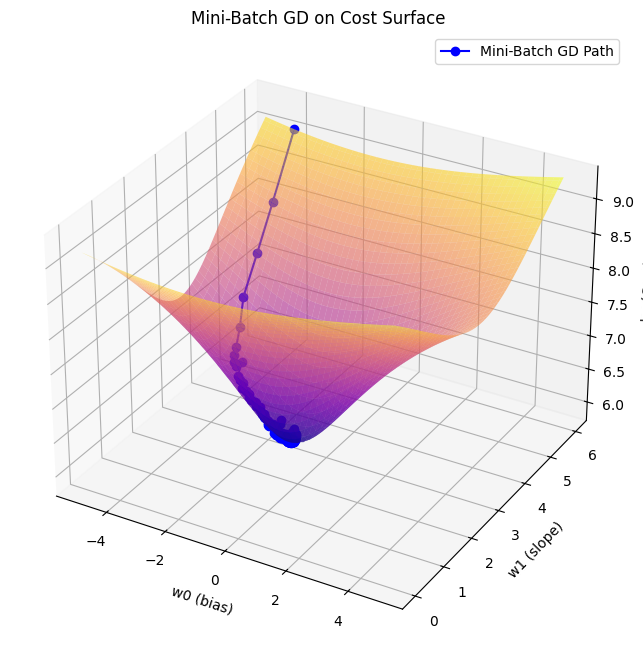

In [ ]:
np.random.seed(42)
n = 100

X = np.linspace(-5, 5, n)
y = 3 * X - 1 + np.random.normal(0, 2, size=n)

init_w = np.array([-4.0, 6.0])

sgd_history = extended_gradient_descent_1D(X, y, init_w, learning_rate=0.02, n_iters=40, mode='sgd')
mbgd_history = extended_gradient_descent_1D(X, y, init_w, learning_rate=0.02, n_iters=40, mode='mbgd', batch_size=16)

print(f'Stochastic GD Final Weights: {sgd_history[-1]}')
print(f'Mini-Batch GD Final Weights: {mbgd_history[-1]}')

import matplotlib.pyplot as plt

# Cost surface
W0 = np.linspace(-5, 5, 100)
W1 = np.linspace(0, 6, 100)
W0, W1 = np.meshgrid(W0, W1)
Z = np.array([[j_function(w0, w1, X, y) for w0, w1 in zip(W0_row, W1_row)] for W0_row, W1_row in zip(W0, W1)])
Z = np.log(Z + 1.5)

fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot surface
ax.plot_surface(W0, W1, Z, cmap='plasma', alpha=0.6)

# Paths
sgd_path = sgd_history
sgd_z = np.log([j_function(w[0], w[1], X, y) + 1.5 for w in sgd_path])
ax.plot(sgd_path[:, 0], sgd_path[:, 1], sgd_z, color='red', marker='o', label='SGD Path')

ax.set_xlabel('w0 (bias)')
ax.set_ylabel('w1 (slope)')
ax.set_zlabel('log(Cost)')
ax.set_title('SGD on Cost Surface')
ax.legend(loc="upper right")
plt.show()

fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot surface
ax.plot_surface(W0, W1, Z, cmap='plasma', alpha=0.6)

mbgd_path = mbgd_history
mbgd_z = np.log([j_function(w[0], w[1], X, y) + 1.5 for w in mbgd_path])
ax.plot(mbgd_path[:, 0], mbgd_path[:, 1], mbgd_z, color='blue', marker='o', label='Mini-Batch GD Path')

ax.set_xlabel('w0 (bias)')
ax.set_ylabel('w1 (slope)')
ax.set_zlabel('log(Cost)')
ax.set_title('Mini-Batch GD on Cost Surface')
ax.legend(loc="upper right")
plt.show()

## **Closing This Chapter**

In this chapter, we built a foundation in **regression** — learning how to fit models to continuous data.
We covered:

* **Linear Regression:** Fitting a line through data points.
* **Multiple Linear Regression:** Using many features to find the best-fit hyperplane in a d-dimensional space.
* **Polynomial Regression:** Using higher-degree terms to capture non-linear patterns.
* Two powerful ways to find the best parameters:

  * **Closed-Form Solution (Normal Equation)**
  * **Gradient Descent**

---

### 🚀 **What’s Next?**

> **Classification**

Regression is all about predicting **continuous** values.
Up next, we step into the world of **Classification** — where we teach machines to predict **discrete** categories instead of numbers.

Let’s get ready to flip from lines and curves to **boundaries and classes!**